# Delayed PID controller

Explores how sensory delay degrades control performance. The `NoisyDelayedPIDController`
observes the lever angle from `delay_ms` milliseconds in the past. Here we fix noise to
zero and search for optimal gains at four delay levels: 10, 25, 50 and 100 ms.

Best parameters are saved to `best_params_delayed_pid.json`. **To skip the grid searches
and jump to the comparison figure, run only the first and last cells.**

In [1]:
import json
import jax
import jax.numpy as jp
import numpy as np
import matplotlib.pyplot as plt
import tqdm

from strategies import NoisyDelayedPIDController
from evaluate import (
    evaluate_strategy, sample_trajectories, plot_trajectory_panel,
    TARGET_DEG,
)

PARAMS_FILE = 'best_params_delayed_pid.json'
DELAYS_MS   = [10, 25, 50, 100]
NOISE_STD   = 0.0   # radians; set > 0 to explore noise

def load_params():
    with open(PARAMS_FILE) as f:
        return json.load(f)

def save_params(params):
    with open(PARAMS_FILE, 'w') as f:
        json.dump(params, f, indent=2)
    print(f'Saved to {PARAMS_FILE}')

## Grid searches

For each delay level we search over `(kp, ki, kd)`. A different delay means a
different buffer size baked into the computation graph, so JAX re-compiles once
per delay — expect a short pause at the start of each loop.

In [3]:
params = load_params()

for delay_ms in DELAYS_MS:
    key = f'delay_{delay_ms}ms'
    print(f'\n--- delay = {delay_ms} ms ---')

    @jax.jit
    def eval_fn(kp, ki, kd, delay_ms=delay_ms):
        strategy = NoisyDelayedPIDController(
            TARGET_DEG, kp=kp, ki=ki, kd=kd,
            delay_ms=delay_ms, noise_std=NOISE_STD,
        )
        return evaluate_strategy(strategy)

    best_score, best_kp, best_ki, best_kd = 0.0, 0.0, 0.0, 0.0
    for kp in tqdm.tqdm(jp.arange(0.0, 15.0, 0.25)):
        for ki in jp.arange(0.0, 0.15, 0.01):
            for kd in jp.arange(0.0, 2.0, 0.1):
                score = eval_fn(kp, ki, kd)
                if score > best_score:
                    best_score = float(score)
                    best_kp, best_ki, best_kd = float(kp), float(ki), float(kd)

    print(f'Best: kp={best_kp:.2f}, ki={best_ki:.3f}, kd={best_kd:.2f}  '
          f'(score {best_score:.2f})')
    params[key] = {'kp': best_kp, 'ki': best_ki, 'kd': best_kd}

save_params(params)


--- delay = 10 ms ---


100%|██████████| 60/60 [03:05<00:00,  3.09s/it]


Best: kp=6.25, ki=0.030, kd=0.30  (score 38.09)

--- delay = 25 ms ---


100%|██████████| 60/60 [03:04<00:00,  3.08s/it]


Best: kp=1.00, ki=0.010, kd=0.10  (score 15.96)

--- delay = 50 ms ---


100%|██████████| 60/60 [03:05<00:00,  3.09s/it]


Best: kp=4.25, ki=0.000, kd=0.00  (score 5.11)

--- delay = 100 ms ---


100%|██████████| 60/60 [03:05<00:00,  3.09s/it]

Best: kp=0.50, ki=0.010, kd=0.00  (score 6.45)
Saved to best_params_delayed_pid.json


## Comparison figure

Each panel shows trajectories under 10 different motor torque levels (colour = torque).
The dashed line marks the target angle.

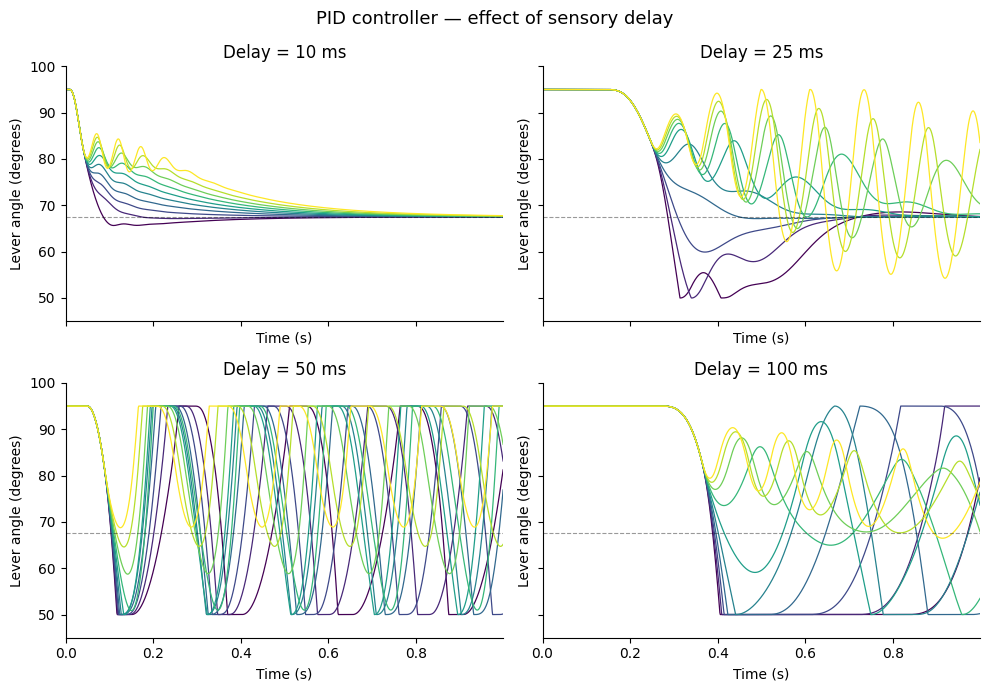

In [5]:
p = load_params()

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)

sm = None
for ax, delay_ms in zip(axes.flat, DELAYS_MS):
    key = f'delay_{delay_ms}ms'
    strategy = NoisyDelayedPIDController(
        TARGET_DEG,
        kp=p[key]['kp'],
        ki=p[key]['ki'],
        kd=p[key]['kd'],
        delay_ms=delay_ms,
        noise_std=NOISE_STD,
    )
    thetas = sample_trajectories(strategy)
    sm = plot_trajectory_panel(ax, thetas, title=f'Delay = {delay_ms} ms')

#fig.colorbar(sm, ax=axes, label='Motor torque (Nm)', shrink=0.6)
fig.suptitle('PID controller — effect of sensory delay', fontsize=13)
plt.tight_layout()
plt.show()